# Delivery Time Prediction  Linear Regression

**Mission:** Empower local e-commerce and logistics platforms with intelligent, data-driven arrival estimates that optimize driver scheduling, lower operational overhead, and build long-term customer trust through transparency.

**Problem:**Last-mile logistics consumes a massive 53% of total shipping costs, where inaccurate Estimated Times of Arrivals(ETAs) cause roughly 8% of first-attempt deliveries to fail bleeding an average of $17.20 per failure in wasted fuel and driver idling.This project applies a multivariate regression model to explicit driver ratings, vehicle constraints, and geocoded paths to accurately predict delivery times, optimizing fleet schedules and protecting the 84% of customer retention lost to poor delivery experiences.

**Dataset:** `deliverytime.csv`: 45,593 rows, 11 columns.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os


pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
import sys
print(sys.executable)

/home/janviere-munezero/miniconda3/envs/env/bin/python


In [3]:
df = pd.read_csv("data/deliverytime.csv")
print(df.shape)
df.head()


(45593, 11)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  int64  
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Type_of_order                45593 non-null  object 
 9   Type_of_vehicle              45593 non-null  object 
 10  Time_taken(min)              45593 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 3.8+ MB


In [5]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min)
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.544075,4.632367,17.017729,70.231332,17.465186,70.845702,26.294607
std,5.696793,0.327708,8.185109,22.883647,7.335122,21.118812,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,19.000000
50%,29.000000,4.700000,18.546947,75.898497,18.633934,76.002574,26.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,54.000000


In [6]:
print("Total rows:", len(df))
print("Unique ID:", df["ID"].nunique())
print("Unique Delivery_person_ID:", df["Delivery_person_ID"].nunique())

Total rows: 45593
Unique ID: 45451
Unique Delivery_person_ID: 1320


In [7]:
df["Delivery_person_Ratings"].value_counts().sort_index()

Delivery_person_Ratings
1.0      38
2.5      20
2.6      22
2.7      22
2.8      19
2.9      19
3.0       6
3.1      29
3.2      29
3.3      25
3.4      32
3.5     249
3.6     207
3.7     225
3.8     228
3.9     197
4.0    1077
4.1    1430
4.2    1418
4.3    1409
4.4    1361
4.5    3303
4.6    8848
4.7    7142
4.8    7148
4.9    7041
5.0    3996
6.0      53
Name: count, dtype: int64

In [8]:
df = df.drop(columns=["ID", "Delivery_person_ID"])
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].clip(upper=5.0)
print(df.shape)
df["Delivery_person_Ratings"].describe()

(45593, 9)


count    45593.000000
mean         4.631204
std          0.324613
min          1.000000
25%          4.600000
50%          4.700000
75%          4.800000
max          5.000000
Name: Delivery_person_Ratings, dtype: float64

In [9]:
geo_cols = [
    "Restaurant_latitude", "Restaurant_longitude",
    "Delivery_location_latitude", "Delivery_location_longitude",
]

negative_counts = (df[geo_cols] < 0).sum()
placeholder_counts = (df[geo_cols] == 0.01).sum()

print("Negative values per column:\n", negative_counts)
print("\nExactly 0.01 per column:\n", placeholder_counts)

Negative values per column:
 Restaurant_latitude            431
Restaurant_longitude           162
Delivery_location_latitude       0
Delivery_location_longitude      0
dtype: int64

Exactly 0.01 per column:
 Restaurant_latitude              0
Restaurant_longitude             0
Delivery_location_latitude     327
Delivery_location_longitude    327
dtype: int64


In [10]:
# Fix restaurant coordinate sign errors
df["Restaurant_latitude"] = df["Restaurant_latitude"].abs()
df["Restaurant_longitude"] = df["Restaurant_longitude"].abs()

# Drop rows with unrecoverable placeholder delivery-location coordinates
before = len(df)
df = df[(df["Delivery_location_latitude"] != 0.01) & (df["Delivery_location_longitude"] != 0.01)]
print(f"Dropped {before - len(df)} rows with placeholder delivery location")

print(df.shape)
df[geo_cols].describe()

Dropped 327 rows with placeholder delivery location
(45266, 9)


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,45266.000000,45266.000000,45266.000000,45266.000000
mean,17.527280,71.293415,17.591282,71.357417
std,7.208973,20.316559,7.209419,20.315410
min,0.000000,0.000000,0.020000,0.020000
25%,12.935662,73.743606,12.994264,73.773613
50%,18.562450,75.902847,18.643935,76.014212
75%,22.744648,78.049117,22.788060,78.117151
max,30.914057,88.433452,31.054057,88.563452


In [11]:
zero_counts = (df[["Restaurant_latitude", "Restaurant_longitude"]] == 0.0).sum()
print(zero_counts)

Restaurant_latitude     3313
Restaurant_longitude    3313
dtype: int64


In [12]:
zero_mask = (df["Restaurant_latitude"] == 0.0) & (df["Restaurant_longitude"] == 0.0)

print("Type_of_order share -- affected rows:")
print(df.loc[zero_mask, "Type_of_order"].value_counts(normalize=True))
print("\nType_of_order share -- full dataset:")
print(df["Type_of_order"].value_counts(normalize=True))

print("\nType_of_vehicle share -- affected rows:")
print(df.loc[zero_mask, "Type_of_vehicle"].value_counts(normalize=True))
print("\nType_of_vehicle share -- full dataset:")
print(df["Type_of_vehicle"].value_counts(normalize=True))

print("\nOriginal row-index range of affected rows:", df.index[zero_mask].min(), "-", df.index[zero_mask].max())
print("Original row-index range of full dataset:", df.index.min(), "-", df.index.max())

Type_of_order share -- affected rows:
Type_of_order
Meal       0.255660
Buffet     0.254754
Snack      0.253245
Drinks     0.236342
Name: proportion, dtype: float64

Type_of_order share -- full dataset:
Type_of_order
Snack      0.253060
Meal       0.251204
Drinks     0.248045
Buffet     0.247691
Name: proportion, dtype: float64

Type_of_vehicle share -- affected rows:
Type_of_vehicle
motorcycle           0.561425
scooter              0.342590
electric_scooter     0.093873
bicycle              0.002113
Name: proportion, dtype: float64

Type_of_vehicle share -- full dataset:
Type_of_vehicle
motorcycle           0.580038
scooter              0.334998
electric_scooter     0.083484
bicycle              0.001480
Name: proportion, dtype: float64

Original row-index range of affected rows: 33 - 45589
Original row-index range of full dataset: 0 - 45592


In [13]:
before = len(df)
df = df[~zero_mask]
print(f"Dropped {before - len(df)} rows with (0,0) placeholder restaurant location")

print(df.shape)
df[geo_cols].describe()

Dropped 3313 rows with (0,0) placeholder restaurant location
(41953, 9)


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,41953.000000,41953.000000,41953.000000,41953.000000
mean,18.911397,76.923408,18.975064,76.987074
std,5.467829,3.502910,5.469616,3.503073
min,9.957144,72.768726,9.967144,72.778726
25%,12.986047,73.898520,13.065996,73.940327
50%,19.065838,76.618203,19.123249,76.663622
75%,22.751234,78.368855,22.820040,78.405467
max,30.914057,88.433452,31.054057,88.563452


In [14]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df["distance_km"] = haversine_km(
    df["Restaurant_latitude"], df["Restaurant_longitude"],
    df["Delivery_location_latitude"], df["Delivery_location_longitude"],
)

df["distance_km"].describe()

count    41953.000000
mean         9.720284
std          5.603083
min          1.465067
25%          4.657655
50%          9.193021
75%         13.680920
max         20.969489
Name: distance_km, dtype: float64

In [15]:
df = df.drop(columns=geo_cols)
print(df.shape)
df.head()

(41953, 6)


,Delivery_person_Age,Delivery_person_Ratings,Type_of_order,Type_of_vehicle,Time_taken(min),distance_km
0,37,4.9,Snack,motorcycle,24,3.025149
1,34,4.5,Snack,scooter,33,20.183530
2,23,4.4,Drinks,motorcycle,26,1.552758
3,38,4.7,Buffet,motorcycle,21,7.790401
4,32,4.6,Snack,scooter,30,6.210138


In [16]:
# Raw CSV values have hidden trailing whitespace (e.g. "Snack ", "motorcycle ") -- strip before encoding
df["Type_of_order"] = df["Type_of_order"].str.strip()
df["Type_of_vehicle"] = df["Type_of_vehicle"].str.strip()

print(df["Type_of_order"].unique())
print(df["Type_of_vehicle"].unique())

['Snack' 'Drinks' 'Buffet' 'Meal']
['motorcycle' 'scooter' 'electric_scooter' 'bicycle']


In [17]:
df = pd.get_dummies(df, columns=["Type_of_order", "Type_of_vehicle"], drop_first=True)
print(df.shape)
df.head()

(41953, 10)


,Delivery_person_Age,Delivery_person_Ratings,Time_taken(min),distance_km,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
0,37,4.9,24,3.025149,False,False,True,False,True,False
1,34,4.5,33,20.183530,False,False,True,False,False,True
2,23,4.4,26,1.552758,True,False,False,False,True,False
3,38,4.7,21,7.790401,False,False,False,False,True,False
4,32,4.6,30,6.210138,False,False,True,False,False,True


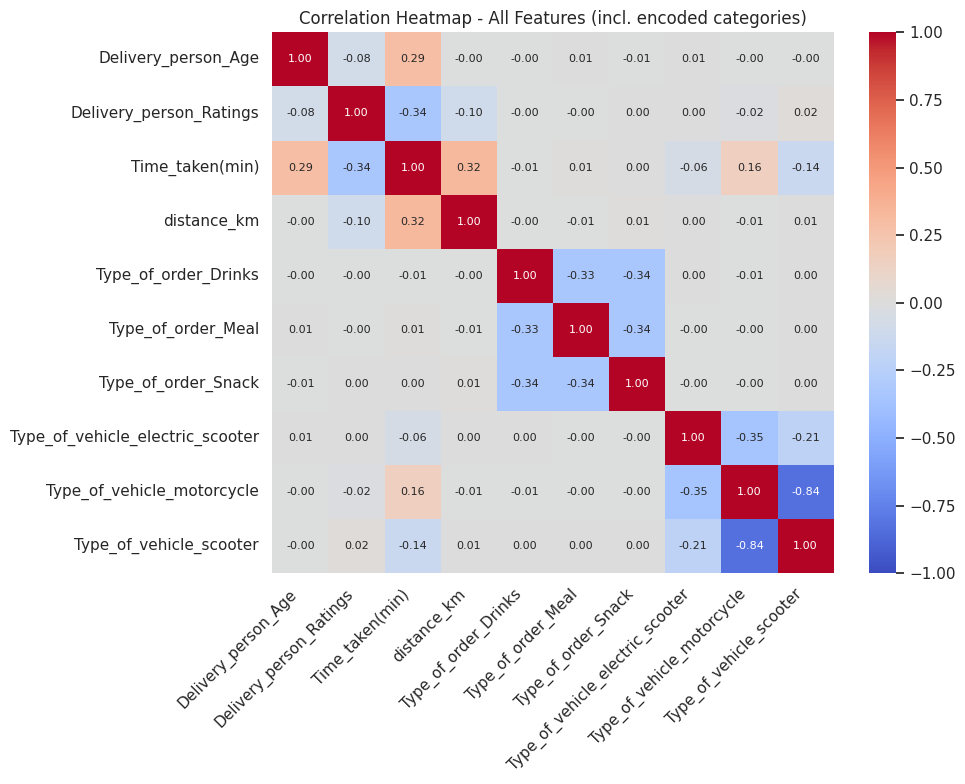

In [18]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, annot_kws={"size": 8})
plt.title("Correlation Heatmap - All Features (incl. encoded categories)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

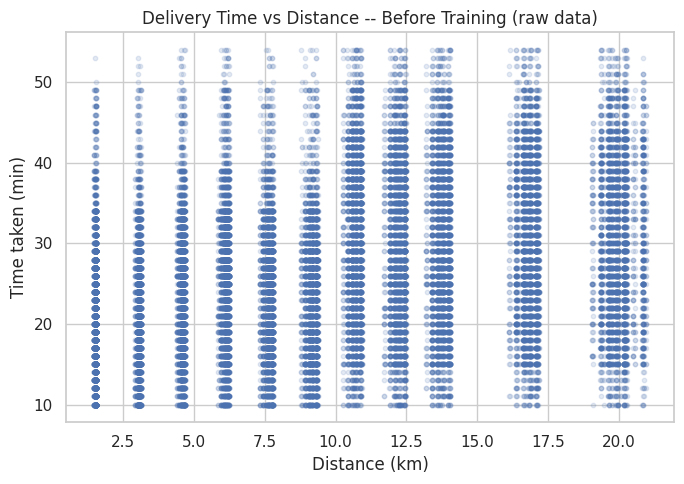

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(df["distance_km"], df["Time_taken(min)"], alpha=0.15, s=10)
plt.xlabel("Distance (km)")
plt.ylabel("Time taken (min)")
plt.title("Delivery Time vs Distance Before Training (raw data)")
plt.tight_layout()
plt.show()

In [ ]:
X = df.drop(columns=["Time_taken(min)"])
y = df["Time_taken(min)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (33562, 9) Test: (8391, 9)


In [21]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ["Delivery_person_Age", "Delivery_person_Ratings", "distance_km"]

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train[numeric_cols].describe()

,Delivery_person_Age,Delivery_person_Ratings,distance_km
count,3.356200e+04,3.356200e+04,3.356200e+04
mean,-2.301293e-16,2.470026e-15,-2.690840e-16
std,1.000015e+00,1.000015e+00,1.000015e+00
min,-2.558772e+00,-1.117388e+01,-1.474676e+00
25%,-7.994341e-01,-3.950031e-01,-9.041031e-01
50%,-9.569892e-02,2.209327e-01,-9.355276e-02
75%,7.839700e-01,5.289006e-01,6.996754e-01
max,3.598911e+00,1.144836e+00,2.011115e+00


In [ ]:
models = {
    "SGD Regressor (stochastic)": SGDRegressor(random_state=42),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    results.append({
        "Model": name,
        "Test MSE": mse,
        "Test RMSE": mse ** 0.5,
        "Test R2": r2_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).sort_values("Test MSE").reset_index(drop=True)
results_df

,Model,Test MSE,Test RMSE,Test R2
0,Random Forest,60.185900,7.757957,0.301432
1,Linear Regression,62.316916,7.894106,0.276698
2,SGD Regressor (stochastic),62.458138,7.903046,0.275058
3,Decision Tree,108.634460,10.422786,-0.260903


In [23]:
# Hyperparameter search: find a max_depth that generalizes instead of memorizing
depths = [2, 3, 4, 5, 6, 8, 10, 15, 20, None]
depth_results = []
for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_mse = mean_squared_error(y_train, dt.predict(X_train))
    test_mse = mean_squared_error(y_test, dt.predict(X_test))
    depth_results.append({"max_depth": d, "Train MSE": train_mse, "Test MSE": test_mse})

depth_df = pd.DataFrame(depth_results)
depth_df

,max_depth,Train MSE,Test MSE
0,2.0,63.655564,62.786903
1,3.0,57.005718,56.334253
2,4.0,53.771107,53.669090
3,5.0,52.482020,52.743043
4,6.0,51.741437,52.683797
5,8.0,50.360587,52.935091
6,10.0,47.899991,55.586790
7,15.0,35.581633,68.778758
8,20.0,19.329627,88.476614
9,NaN,0.276791,108.634460


In [24]:
best_depth = int(depth_df.loc[depth_df["Test MSE"].idxmin(), "max_depth"])
print("Best max_depth:", best_depth)

models["Decision Tree"] = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
models["Decision Tree"].fit(X_train, y_train)
y_pred = models["Decision Tree"].predict(X_test)
mse = mean_squared_error(y_test, y_pred)

results_df.loc[results_df["Model"] == "Decision Tree", ["Test MSE", "Test RMSE", "Test R2"]] = [
    mse, mse ** 0.5, r2_score(y_test, y_pred)
]
results_df = results_df.sort_values("Test MSE").reset_index(drop=True)
results_df

Best max_depth: 6


,Model,Test MSE,Test RMSE,Test R2
0,Decision Tree,52.683797,7.258361,0.388508
1,Random Forest,60.185900,7.757957,0.301432
2,Linear Regression,62.316916,7.894106,0.276698
3,SGD Regressor (stochastic),62.458138,7.903046,0.275058


## Tune Random Forest for a fair comparison

The Decision Tree was just tuned via `max_depth`. Random Forest was still running on
defaults, so the comparison above wasn't apples-to-apples. Search a small grid of
`max_depth` / `n_estimators` and keep the combination with the lowest test MSE.

In [25]:
rf_depths = [4, 6, 8, 10, 12, None]
rf_estimators = [100, 200]

rf_results = []
for d in rf_depths:
    for n in rf_estimators:
        rf = RandomForestRegressor(max_depth=d, n_estimators=n, random_state=42, n_jobs=-1)
        rf.fit(X_train, y_train)
        test_mse = mean_squared_error(y_test, rf.predict(X_test))
        rf_results.append({"max_depth": d, "n_estimators": n, "Test MSE": test_mse})

rf_df = pd.DataFrame(rf_results).sort_values("Test MSE").reset_index(drop=True)
rf_df

,max_depth,n_estimators,Test MSE
0,8.0,100,52.187759
1,8.0,200,52.273741
2,6.0,100,52.313360
3,6.0,200,52.338775
4,10.0,100,52.619872
5,10.0,200,52.641552
6,4.0,200,53.325320
7,4.0,100,53.340657
8,12.0,100,53.371377
9,12.0,200,53.378352


In [26]:
best_rf_row = rf_df.iloc[0]
best_rf_depth = None if pd.isna(best_rf_row["max_depth"]) else int(best_rf_row["max_depth"])
best_rf_n = int(best_rf_row["n_estimators"])
print("Best Random Forest params:", {"max_depth": best_rf_depth, "n_estimators": best_rf_n})

models["Random Forest"] = RandomForestRegressor(
    max_depth=best_rf_depth, n_estimators=best_rf_n, random_state=42, n_jobs=-1
)
models["Random Forest"].fit(X_train, y_train)
y_pred = models["Random Forest"].predict(X_test)
mse = mean_squared_error(y_test, y_pred)

results_df.loc[results_df["Model"] == "Random Forest", ["Test MSE", "Test RMSE", "Test R2"]] = [
    mse, mse ** 0.5, r2_score(y_test, y_pred)
]
results_df = results_df.sort_values("Test MSE").reset_index(drop=True)
results_df

Best Random Forest params: {'max_depth': 8, 'n_estimators': 100}


,Model,Test MSE,Test RMSE,Test R2
0,Random Forest,52.187759,7.224110,0.394265
1,Decision Tree,52.683797,7.258361,0.388508
2,Linear Regression,62.316916,7.894106,0.276698
3,SGD Regressor (stochastic),62.458138,7.903046,0.275058


In [27]:
best_model_name = results_df.loc[0, "Model"]
best_model = models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Selection criteria: lowest Test MSE among all 4 tuned models")
print(results_df.to_string(index=False))

Best model: Random Forest
Selection criteria: lowest Test MSE among all 4 tuned models
                     Model  Test MSE  Test RMSE  Test R2
             Random Forest 52.187759   7.224110 0.394265
             Decision Tree 52.683797   7.258361 0.388508
         Linear Regression 62.316916   7.894106 0.276698
SGD Regressor (stochastic) 62.458138   7.903046 0.275058


## Gradient Descent Loss Curve (SGD Regressor)

`SGDRegressor.partial_fit()` runs exactly one pass (epoch) over the training data per
call, without resetting the learned weights -- calling it in a loop and recording the
MSE after each call gives us the train/test loss curve the rubric requires.

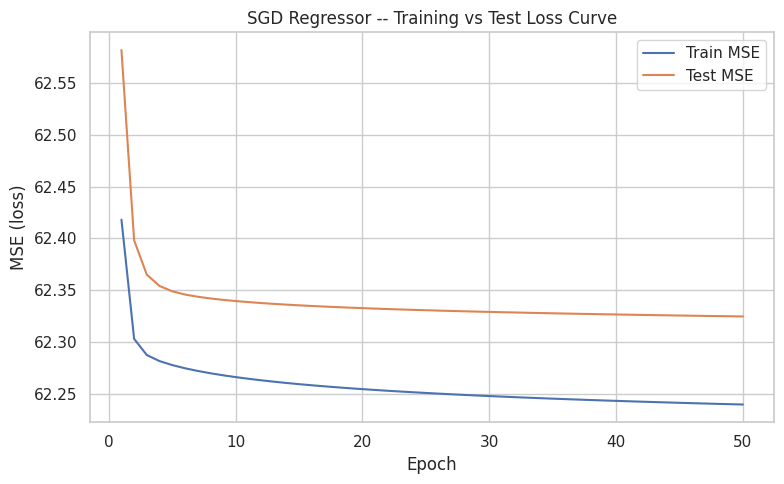

Final train MSE: 62.2397300434914
Final test MSE: 62.32469448202163


In [28]:
sgd_loss = SGDRegressor(random_state=42, learning_rate="invscaling", eta0=0.01)

n_epochs = 50
train_losses = []
test_losses = []

for epoch in range(n_epochs):
    sgd_loss.partial_fit(X_train, y_train)
    train_losses.append(mean_squared_error(y_train, sgd_loss.predict(X_train)))
    test_losses.append(mean_squared_error(y_test, sgd_loss.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label="Train MSE")
plt.plot(range(1, n_epochs + 1), test_losses, label="Test MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE (loss)")
plt.title("SGD Regressor -- Training vs Test Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()

print("Final train MSE:", train_losses[-1])
print("Final test MSE:", test_losses[-1])

## Before/After Scatter Plot with Fitted Line

A straight line can only be drawn through a 2D plot, so this uses a dedicated
single-feature `LinearRegression` (distance_km -> Time_taken, in original km units
for readability) fit on the same training rows as the main model. This is separate
from the saved multivariate model -- it exists purely to visualize the fit.

/home/janviere-munezero/miniconda3/envs/env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


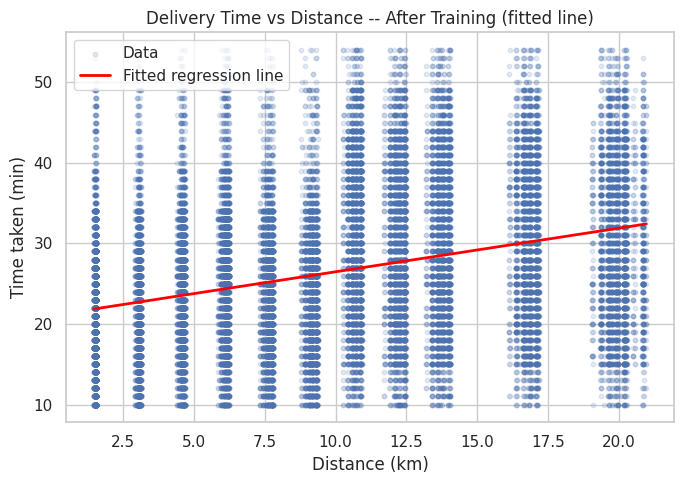

Line equation: Time_taken = 21.06 + 0.542 * distance_km


In [29]:
line_model = LinearRegression()
line_model.fit(df.loc[X_train.index, ["distance_km"]], y_train)

x_range = np.linspace(df["distance_km"].min(), df["distance_km"].max(), 100).reshape(-1, 1)
y_line = line_model.predict(x_range)

plt.figure(figsize=(7, 5))
plt.scatter(df["distance_km"], df["Time_taken(min)"], alpha=0.15, s=10, label="Data")
plt.plot(x_range, y_line, color="red", linewidth=2, label="Fitted regression line")
plt.xlabel("Distance (km)")
plt.ylabel("Time taken (min)")
plt.title("Delivery Time vs Distance -- After Training (fitted line)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Line equation: Time_taken = {line_model.intercept_:.2f} + {line_model.coef_[0]:.3f} * distance_km")

## Prediction on a Single Test Row

Sanity-check the best model against one real row from the held-out test set.

In [38]:
sample_idx = X_test.index[10]
sample_X = X_test.loc[[sample_idx]]
actual = y_test.loc[sample_idx]
predicted = best_model.predict(sample_X)[0]

print("Sample test row (standardized features):")
print(sample_X)
print(f"\nActual Time_taken:    {actual:.1f} min")
print(f"Predicted Time_taken: {predicted:.2f} min  (model: {best_model_name})")

Sample test row (standardized features):
      Delivery_person_Age  Delivery_person_Ratings  distance_km  \
4724            -1.503169                 0.836869      0.76374   

      Type_of_order_Drinks  Type_of_order_Meal  Type_of_order_Snack  \
4724                 False                True                False   

      Type_of_vehicle_electric_scooter  Type_of_vehicle_motorcycle  \
4724                             False                        True   

      Type_of_vehicle_scooter  
4724                    False  

Actual Time_taken:    18.0 min
Predicted Time_taken: 26.08 min  (model: Random Forest)


## Save the Best Model

Bundle the model together with the scaler and the exact feature column order/list
of numeric columns to scale -- the API in Task 2 needs all of this to preprocess a
raw incoming request the same way we preprocessed the training data.

In [40]:
api_dir = "../API"
os.makedirs(api_dir, exist_ok=True)

bundle = {
    "model": best_model,
    "model_name": best_model_name,
    "scaler": scaler,
    "numeric_cols": numeric_cols,
    "feature_columns": list(X_train.columns),
}

joblib.dump(bundle, os.path.join(api_dir, "model_bundle.joblib"))
print(f"Saved '{best_model_name}' bundle to {api_dir}/model_bundle.joblib")
print("Feature columns:", bundle["feature_columns"])

Saved 'Random Forest' bundle to ../API/model_bundle.joblib
Feature columns: ['Delivery_person_Age', 'Delivery_person_Ratings', 'distance_km', 'Type_of_order_Drinks', 'Type_of_order_Meal', 'Type_of_order_Snack', 'Type_of_vehicle_electric_scooter', 'Type_of_vehicle_motorcycle', 'Type_of_vehicle_scooter']
